## Baseline (0, 1)

1. For real flags combined with wideband full-time flags, the 2D+1D algorithm performs better than the 1D+1D algorithm, as shown by the histogram. In the two-dimensional time–frequency plots, the 1D+1D algorithm fails to reconstruct some of the flagged regions.

2. For real flags combined with narrowband long-time flags (as shown by the histogram), the 2D+1D algorithm also performs better than the 1D+1D algorithm.

## Baselines (0, 5) and (0, 10)

1. For all simulated flagging patterns combined with real flags, the 1D+1D and frequency-only algorithms fail to reconstruct some regions in the two-dimensional time–frequency plane.

2. For real flags combined with wideband full-time flags, all algorithms fail to reconstruct some flagged regions, with the '1D_1D' and 'fre' algorithm showing the poorest performance.




gprlim path:
/Users/alliswell48/gprlim/gprlim/__init__.py

utils_inpaint module path:
/Users/alliswell48/radio_gpr_work/shao1/2.corrupt_data/utils_load.py

gp_utils path:
/Users/alliswell48/radio_gpr_work/shao1/2.corrupt_data/../../gp_utils.py


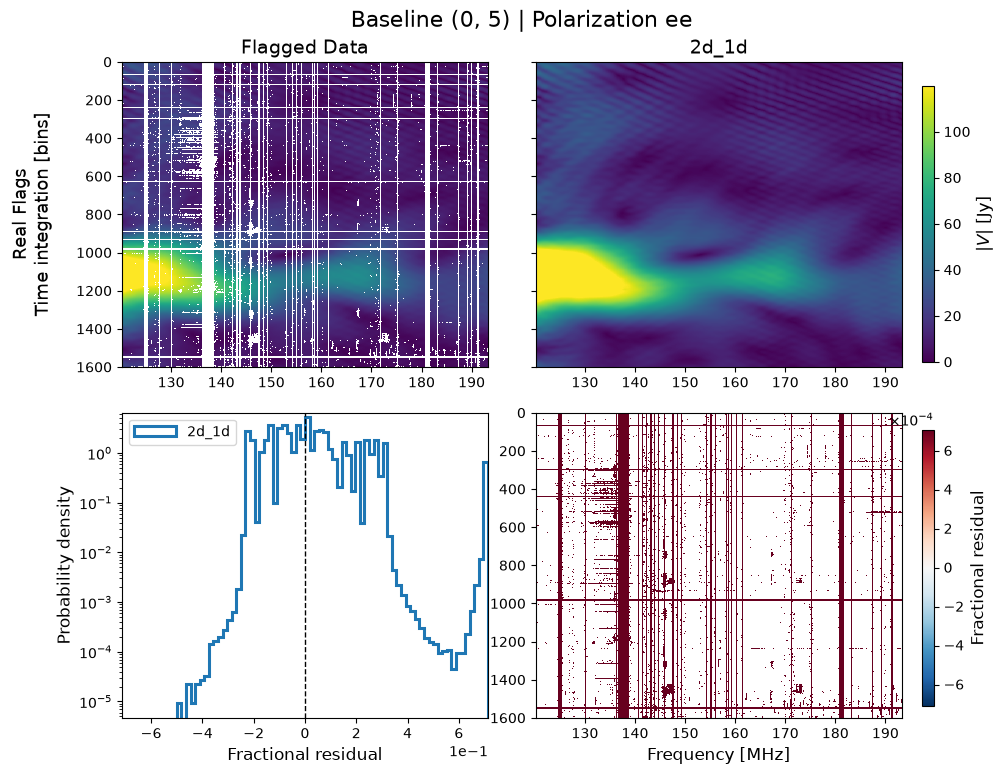

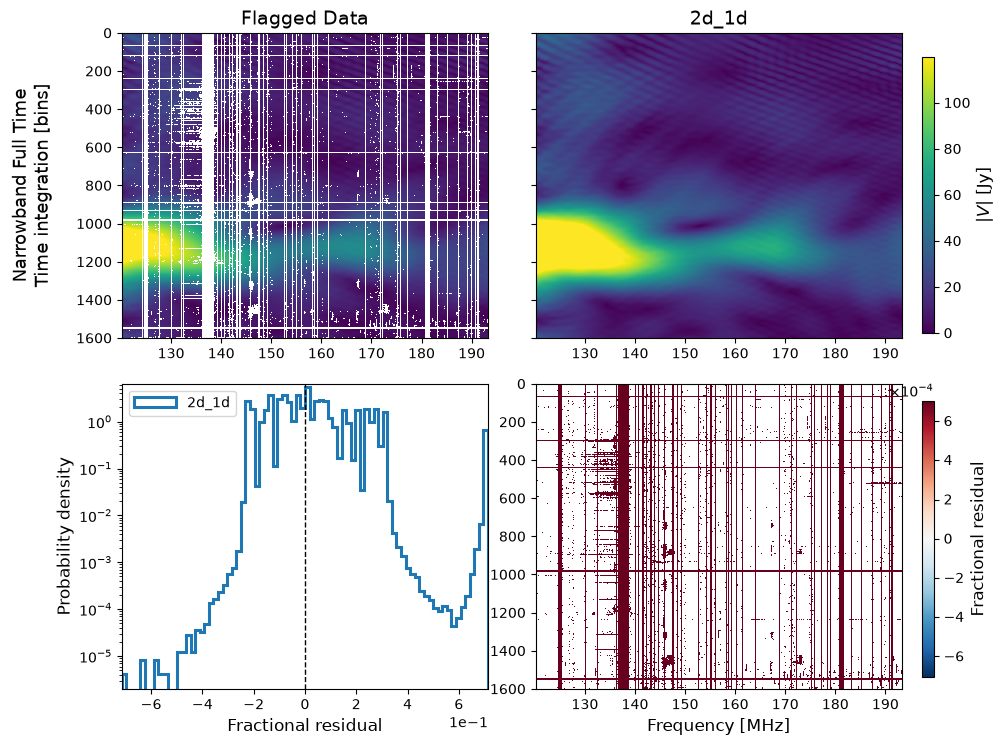

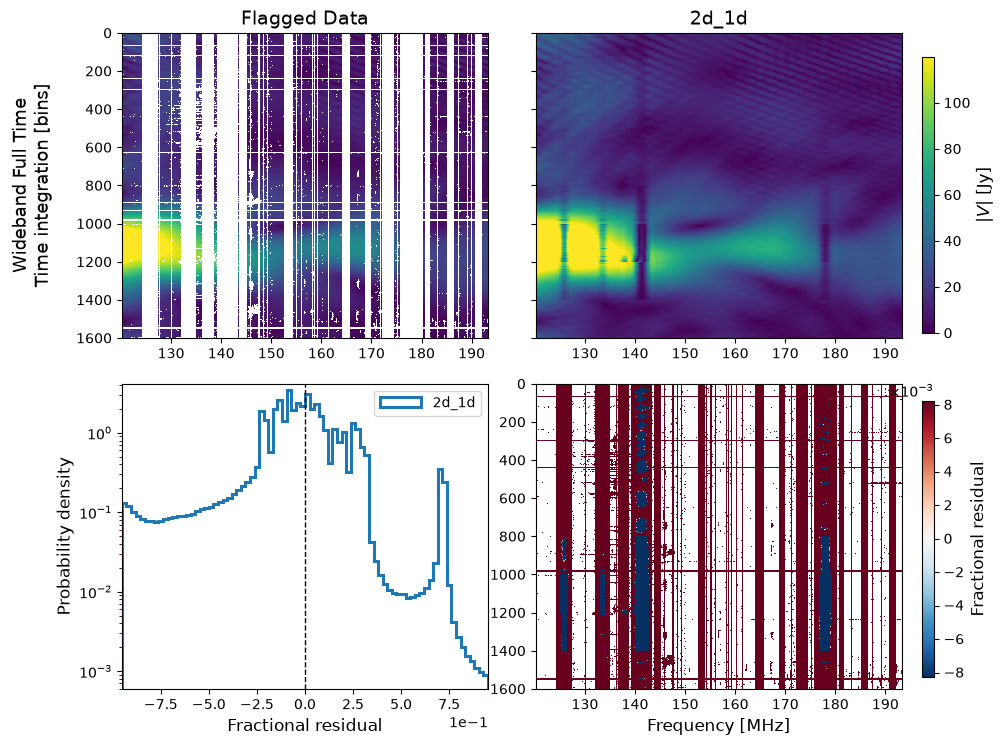

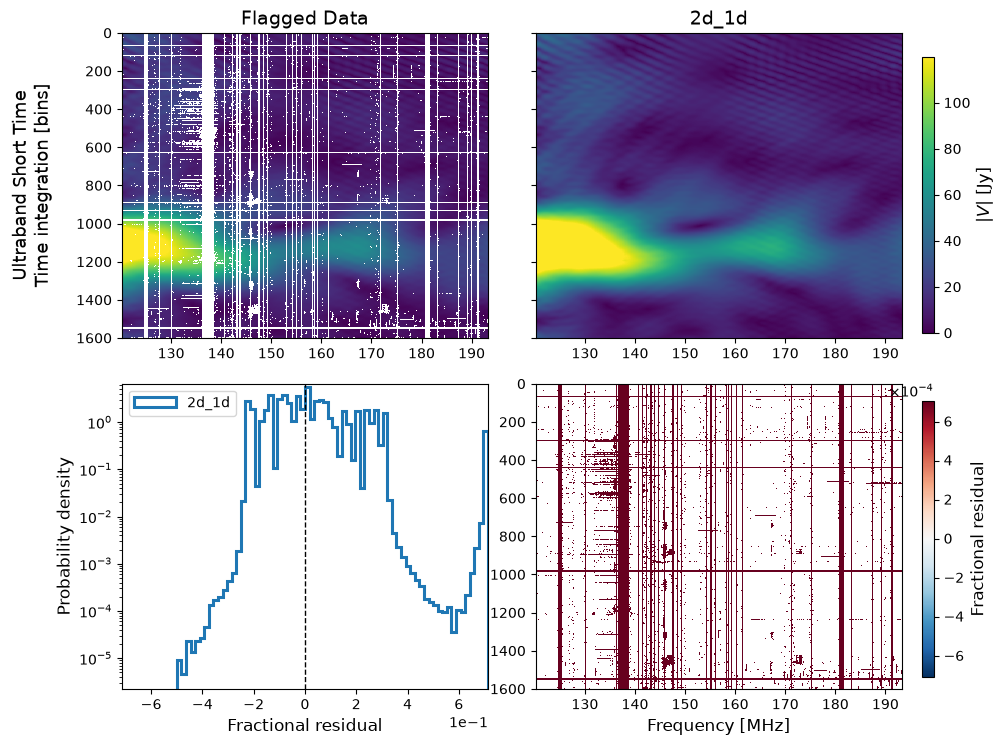

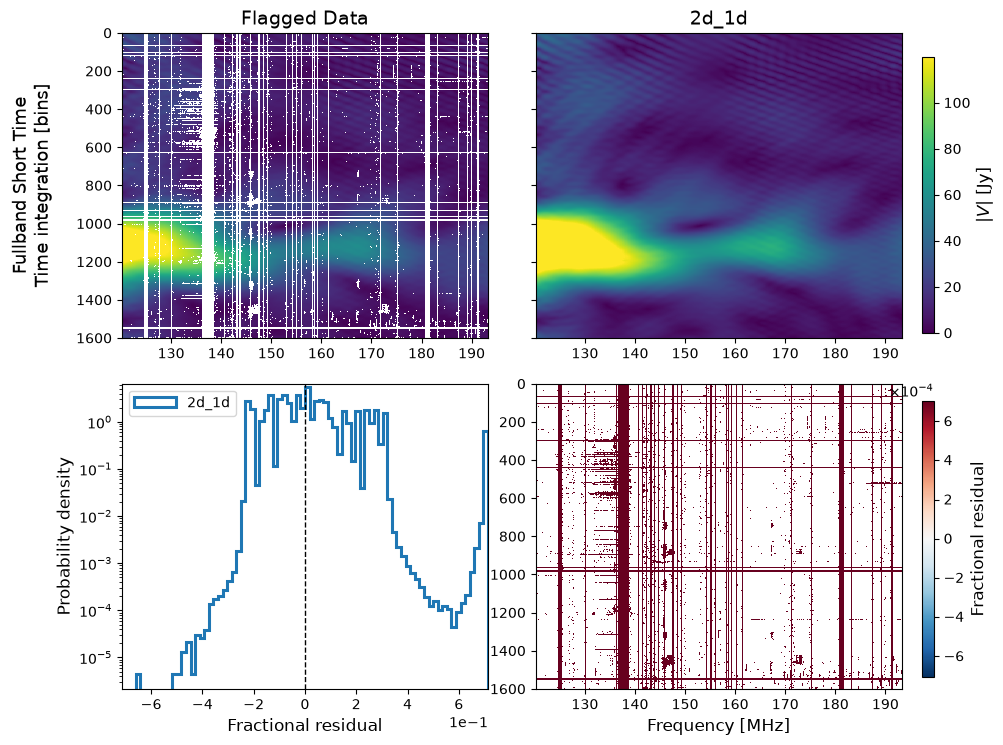

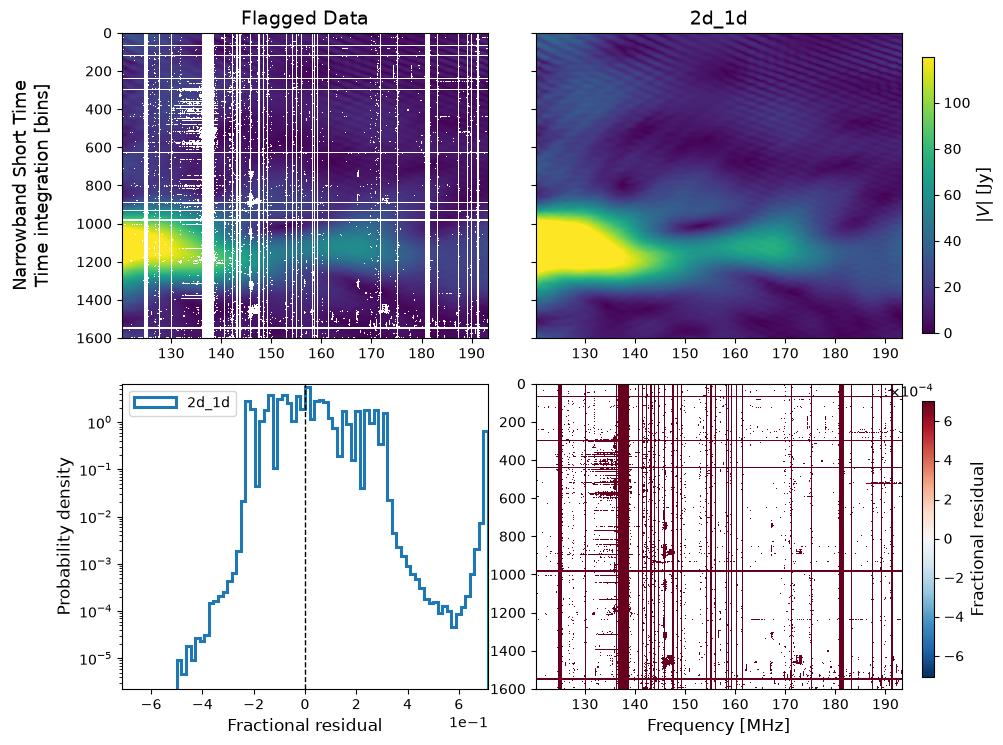

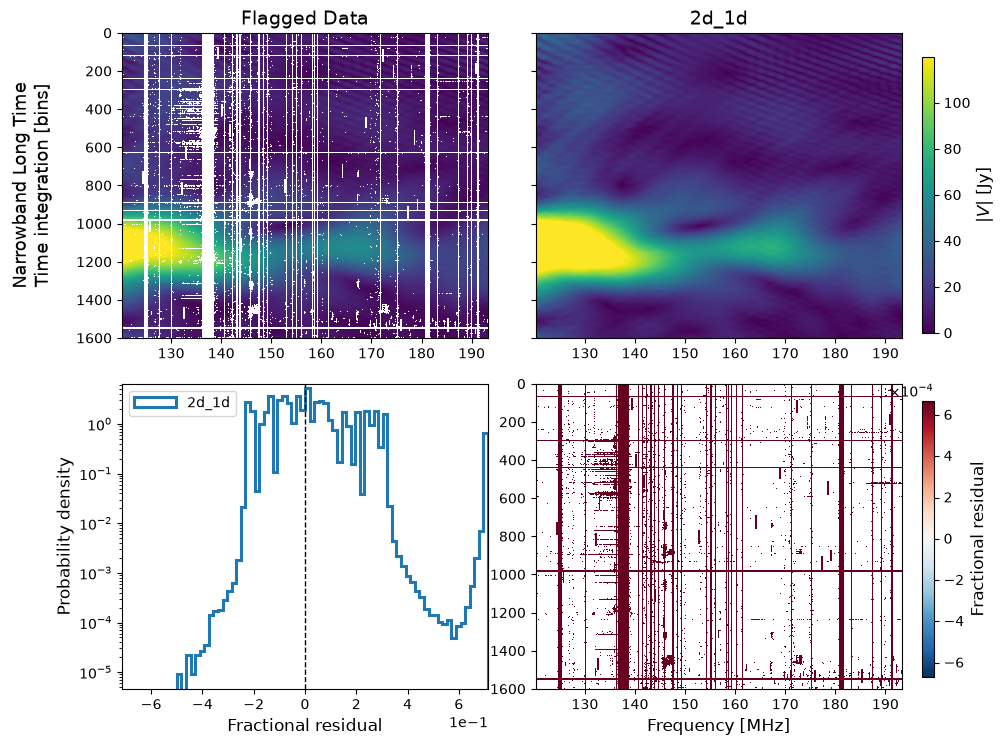

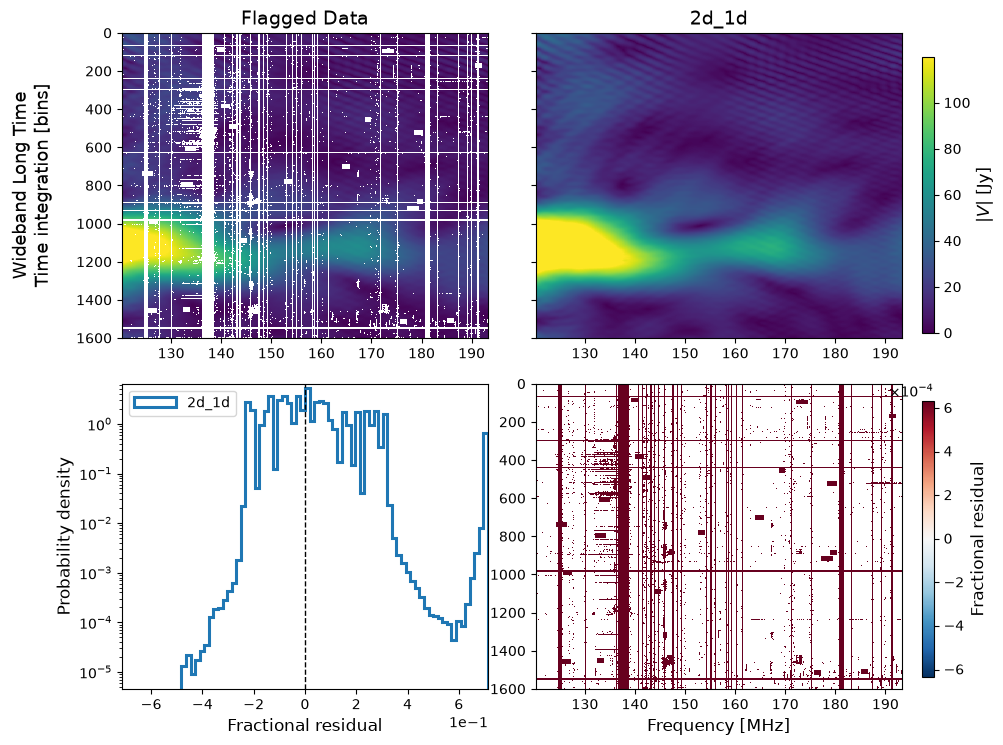

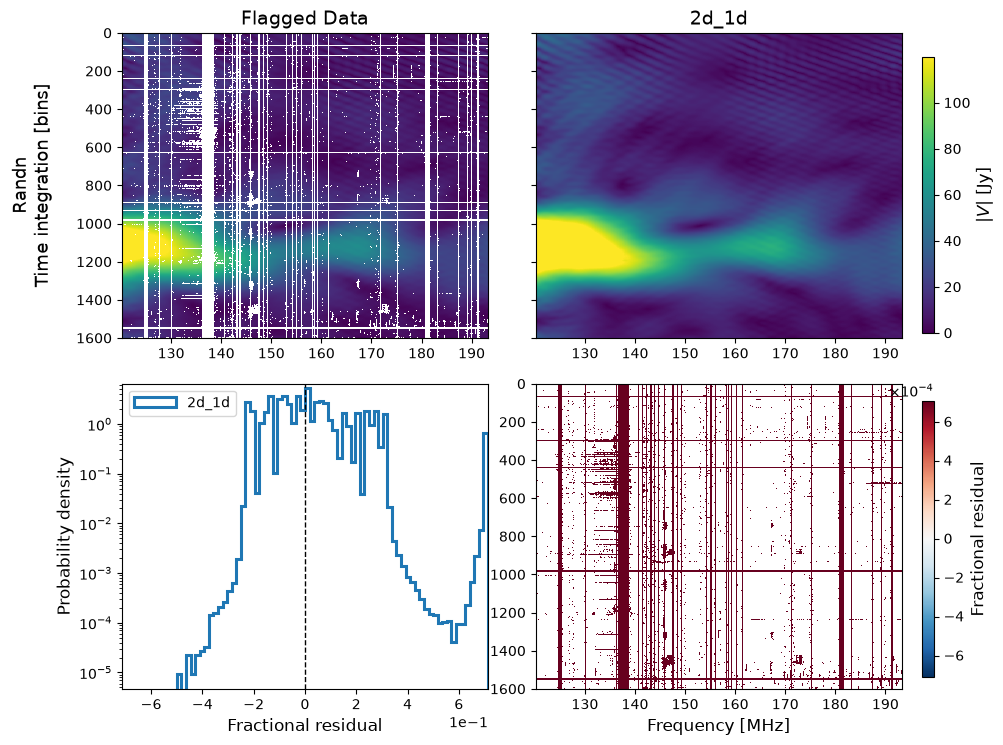

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch
import glob

import sys
sys.path.append('./')
import utils_load

from utils_load import save_vd_inp,load_vd_inp,save_hist_residual

from utils_plot import plot_inpainting_summary

from pyuvdata import UVData
import bayeslim as ba

import gpytorch

import gprlim
from gprlim import kernels
from bayeslim.fft import FFT


torch.set_default_dtype(torch.float64)

sys.path.append('../../')
import gp_utils
import importlib
importlib.reload(gp_utils)

import inspect
print("gprlim path:")
print(gprlim.__file__)

print("\nutils_inpaint module path:")
print(inspect.getmodule(save_vd_inp).__file__)

print("\ngp_utils path:")
print(gp_utils.__file__)






gpytorch.settings.max_cholesky_size._set_value(1_000)

torch.set_default_dtype(torch.float64)
device = 'cpu'



# 1. load all the data (except for the first 50 integrations which are wrong)
flag_file='/Users/alliswell48/radio_gpr_work/shao1/1.ideal_mock/gpr_data/version2/zen.h6c_idr3.2459951.flag_waterfall_round2.npz'
freq_chans = range(0, 600)
time_ints = range(80, 1680)

#2.
inflate_data = False
add_gains = True
add_noise = False
add_reflection = False



# 3.specify the inpaint method [ '2d','2d_1d', '1d_1d', 'freq', 'time']
inpaint_method_all = [ '2d_1d']  #136

# 4. specify the number of time chunks to operate over
Ntime_chunks = 200


#5.real falg
add_real_flags = True #

# 6.simulate flags, can add None+real  #136
flag_types_all = [
    None,
    'narrowband_full_time',
    'wideband_full_time',
    'ultraband_short_time',
    'fullband_short_time',
    'narrowband_short_time',
    'narrowband_long_time',
    'wideband_long_time',
    'randn',
]



#7. polo
polsi='ee'#,'nn'

# 8. baseline
blall=[(0, 5)]   #136

# 9.specify data
#dfile = 'gpr_data/version2/zen.h6c_idr2_validation.sum.uvh5'
dfile = sorted(glob.glob('/Volumes/YUNYUNShao/gpr_data/corrupted data/zen.h6c_idr2_validation.24582*.sum.coupled.h5'))




# load autocorrelation and metadata
vd, meta = gp_utils.load_uvdata(
    dfile, bls=[(0, 0)], pols=[polsi], time_ints=time_ints, freq_chans=freq_chans,
)
autocorr = vd.data[0,0]

freqs = meta['freqs'] / 1e6
lsts = meta['lsts']
times = (meta['times'] - meta['times'][0]) * 24 * 3600
Ntimes = len(times)
Nfreqs = len(freqs)
reds = meta['reds']

# get antenna information
antp = meta['antp']
ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

# get baseline information
red_bls = meta['bls']
all_pols = meta['pols']
reds = meta['reds']

# get noise standard deviation
noise_amp = autocorr.real / np.sqrt(np.diff(meta['times'])[0]*24*3600 * np.diff(meta['freqs'])[0])

# pick a representative baseline to load and model (start with 0)





for bl in blall:
    #bl = (0, 5)

    # this gets the index in the redundant set that this baseline falls in
    red_ind = np.where([bl in red for red in reds])[0][0]
    bls = reds[red_ind][:]
    bl_vec = antp[bls[0][1]] - antp[bls[0][0]]
    bl_len = bl_vec.norm()


    # load single baseline data
    vd, meta = gp_utils.load_uvdata(
        dfile,
        bls=bls,
        time_ints=time_ints,
        freq_chans=freq_chans,
        pols=[polsi], #['nn']
        device=device,
    )

    #inflate_data = True

    #False
    if inflate_data and vd.Nbls == 1:
        vd = vd.inflate_by_redundancy(bls=reds[red_ind])

    #add_reflection = False

    if add_reflection:
        vd.data *= (1 + 1e-2 * (torch.exp(2j*np.pi*2000e-9*freqs*1e6) + torch.exp(-2j*np.pi*2000e-9*freqs*1e6)))

    #add_gains = False
    #True
    if add_gains:
        G = torch.randn(vd.Nbls) / 10 + 1
        vd.data *= G[:, None, None]


    # fg 1e0
    #add_noise = False

    ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-10  



    if add_noise:
        ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-6
        vd.data += ns_draw




    # 1D FT across frequency
    FT1 = FFT(dim=-1, N=vd.data.shape[-1], ndim=2, window='bh', dx=(freqs[1]-freqs[0])/1e3)

    # 1D FT across time
    FT2 = FFT(dim=-2, N=vd.data.shape[-2], ndim=2, window='bh', dx=(lsts[1]-lsts[0])*12/np.pi*3600/1e3)




    # simulate flags

    for flag_idx, flag_typesi in enumerate(flag_types_all):  #137
            
            
        flag_types = [flag_typesi]
        flag_N = [20]

        # draw flags
        flags = gp_utils.simulate_flags(flag_types, flag_N, Ntimes, Nfreqs, seed=0)

        # if add_gains, draw new flags for each baseline
        if add_gains:
            flags = flags.expand(vd.data.shape[-3:]).clone()

            for i in range(1, vd.Nbls):
                flags[i] = gp_utils.simulate_flags(flag_types, flag_N, Ntimes, Nfreqs, seed=i)

        # add real flags
        if add_real_flags:
            flg = np.load(flag_file)["flags"][time_ints][:, freq_chans, 0]
            flags += torch.as_tensor(flg, device=device)

        flagged_times = flags.all(dim=-1, keepdim=True).expand_as(flags)

        # generate noise variance
        noise_var = noise_amp.pow(2).expand(flags.shape).clone() * 1e-5
        noise_var[flags] = noise_var.mean() * 1e6

        # ========================================================
        # Prepare plotting data   #137
        # ========================================================

        method_results = []
        histogram_residuals = []
        plot_residuals = []

        # All redundant baselines: [Nbls, Ntimes, Nfreqs]
        data_true_all = vd.data[0, 0, :]

        # Baseline index 0: [Ntimes, Nfreqs]
        data_true_plot = data_true_all[0]

        # Expand flags only for plotting and histogram calculation
        flags_all = flags.expand_as(data_true_all).bool()
        flags_plot = flags_all[0]

        # White pixels represent flagged regions
        flagged_data = data_true_plot.clone()
        flagged_data[flags_plot] = torch.nan

        # Shared data color scale
        dmax = torch.quantile(
            data_true_plot.abs().detach().cpu(),
            0.99,
        ).item()

        eps = torch.finfo(data_true_plot.real.dtype).eps

        extent = [
            float(freqs[0]),
            float(freqs[-1]),
            Ntimes,
            0,
        ]

        # ========================================================
        # Loop over inpainting methods
        # ========================================================
     
        
        for inpaint_methodi in inpaint_method_all:
            inpaint_method = inpaint_methodi

            # load data from Great Lakes
            vd_inp = load_vd_inp(
                root_dir=(
                    "/Volumes/YUNYUNShao/"
                    "radio_gpr_work_great_lake/"
                    "4.shao_instru_gain_less/inpaint_results"
                ),
                vd=vd,
                bl=bl,
                flag_typesi=flag_typesi,
                add_real_flags=add_real_flags,
                inpaint_method=inpaint_method,
                freq_chans=freq_chans,
                time_ints=time_ints,
                polsi=polsi,
                device=device,
                Ntime_chunks=Ntime_chunks,
            )

            # All redundant baselines: [Nbls, Ntimes, Nfreqs]
            data_inp_all = vd_inp.data[0, 0, :].detach().clone()

            # Baseline index 0: [Ntimes, Nfreqs]
            data_inp_plot = data_inp_all[0]

            # ====================================================
            # Histogram residual
            # All redundant baselines, flagged pixels only
            # ====================================================

            frac_resid_all = torch.full_like(data_true_all.abs(), torch.nan)

            valid_hist_mask = (
                flags_all
                & torch.isfinite(data_true_all.abs())
                & torch.isfinite(data_inp_all.abs())
                & (data_true_all.abs() > eps)
            )

            frac_resid_all[valid_hist_mask] = (
                data_inp_all.abs()[valid_hist_mask]
                - data_true_all.abs()[valid_hist_mask]
            ) / data_true_all.abs()[valid_hist_mask]

            
            
            valid_hist_resid = frac_resid_all[
                torch.isfinite(frac_resid_all)
            ]

            histogram_residuals.append(
                valid_hist_resid.detach().cpu()
            )
            
            save_hist_residual(
                root_dir="hist_residual_gain",
                valid_hist_resid=valid_hist_resid,
                bl=bl,
                flag_typesi=flag_typesi,
                add_real_flags=add_real_flags,
                inpaint_method=inpaint_method,
                freq_chans=freq_chans,
                time_ints=time_ints,
                polsi=polsi,
                Ntime_chunks=Ntime_chunks,
            )


            
            # ====================================================
            # 2D residual image
            # Baseline index 0, flagged pixels only
            # ====================================================

            frac_resid_plot = torch.full_like(data_true_plot.abs(), torch.nan)

            valid_plot_mask = (
                flags_plot
                & torch.isfinite(data_true_plot.abs())
                & torch.isfinite(data_inp_plot.abs())
                & (data_true_plot.abs() > eps)
            )

            frac_resid_plot[valid_plot_mask] = (
                data_inp_plot.abs()[valid_plot_mask]
                - data_true_plot.abs()[valid_plot_mask]
            ) / data_true_plot.abs()[valid_plot_mask]

            valid_plot_resid = frac_resid_plot[
                torch.isfinite(frac_resid_plot)
            ]

            plot_residuals.append(
                valid_plot_resid.detach().cpu()
            )

            method_results.append(
                {
                    "method": inpaint_methodi,
                    "data": data_inp_plot,
                    "residual": frac_resid_plot,
                    "hist_residual": frac_resid_all,
                }
            )

            del vd_inp
            del data_inp_all
            del data_inp_plot
            





        # ========================================================
        # Common residual-image scale
        # ========================================================

        resid_max = torch.cat(plot_residuals).abs().max().item()
        resid_limit = resid_max / 2000

        # ========================================================
        # Common histogram range
        # ========================================================

        hist_all = torch.cat(histogram_residuals).numpy()
        hist_limit = np.quantile(np.abs(hist_all), 0.995)

        # ========================================================
        # Figure title
        # ========================================================

        if flag_typesi is None:
            flag_title = "Real Flags" if add_real_flags else "No Flags"
        else:
            flag_title = flag_typesi.replace("_", " ").title()

        # ========================================================
        # Colormaps
        # ========================================================

        cmap_data = plt.cm.viridis.copy()
        cmap_data.set_bad("white")

        cmap_resid = plt.cm.RdBu_r.copy()
        cmap_resid.set_bad("white")

        # ========================================================
        # Plot using utils_plot.py
        # ========================================================

        fig, axes = plot_inpainting_summary(
            method_results=method_results,
            flagged_data=flagged_data,
            extent=extent,
            dmax=dmax,
            resid_limit=resid_limit,
            hist_limit=hist_limit,
            cmap_data=cmap_data,
            cmap_resid=cmap_resid,
            Ntimes=Ntimes,
            flag_title=flag_title,
            bl=bl,
            polsi=polsi,
            flag_idx=flag_idx,
            display_fractionx=1.0,
            display_fractiony=1.2,
        )
        


        plt.show()
        plt.close(fig)

        del method_results
        del histogram_residuals
        del plot_residuals



In [8]:
1

1

In [23]:
import importlib
import utils_plot

importlib.reload(utils_plot)

from utils_plot import plot_inpainting_summary